In [9]:
import numpy as np
from md_Helpers.simulation import get_or_make_thermalized_state


eos_n_fcc_cells = [10, 15, 20, 25, 30]

eos_temp_start = 0.70
eos_temp_stop = 1.00
eos_temp_step = 0.05
eos_temps = np.round(np.arange(eos_temp_start, eos_temp_stop + eos_temp_step, eos_temp_step), 3)

eos_density_start = 0.50
eos_density_stop = 0.80
eos_density_step = 0.05
eos_densities = np.round(np.arange(eos_density_start, eos_density_stop + eos_density_step, eos_density_step), 3)


In [ ]:
for ncells in eos_n_fcc_cells:
    for temp in eos_temps:
        for density in eos_densities:
            result = get_or_make_thermalized_state(
                n_fcc_cells=ncells,
                target_rho=density,
                kT=temp,
                nsteps=1_000_000,
            )

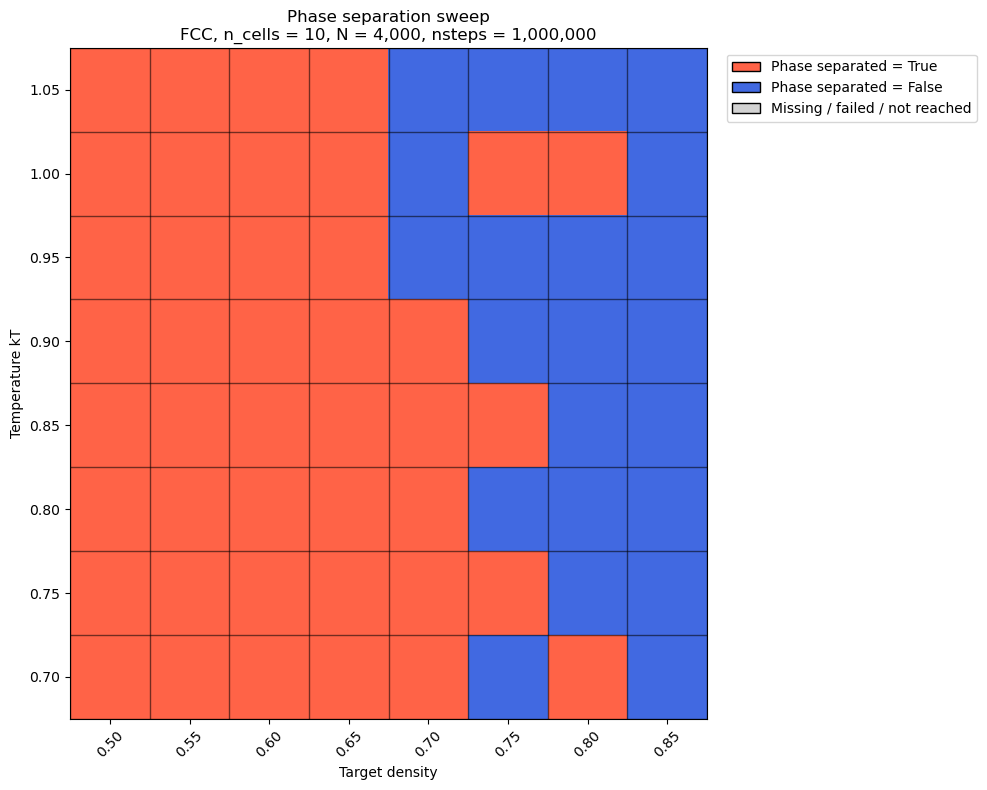

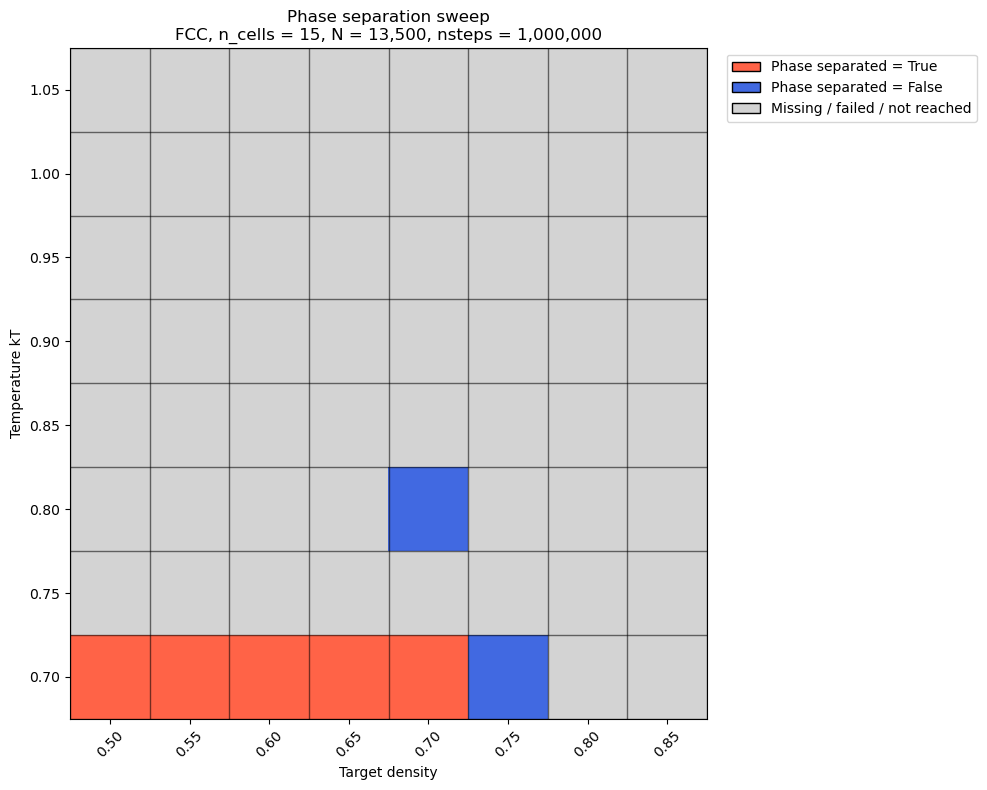

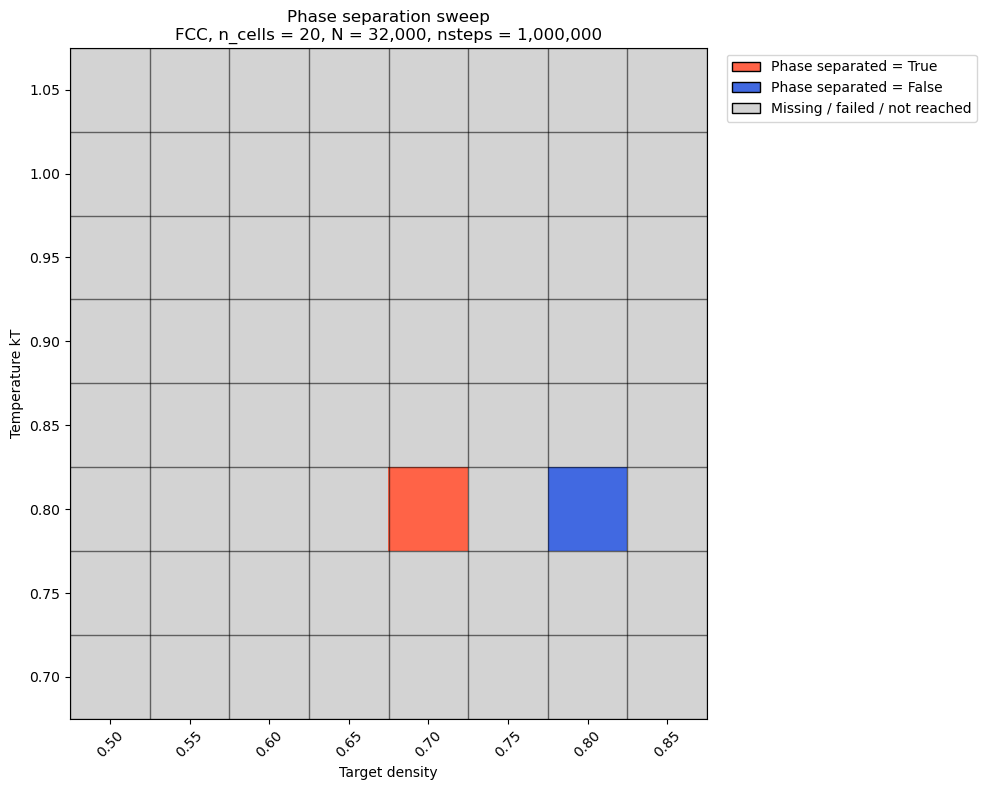

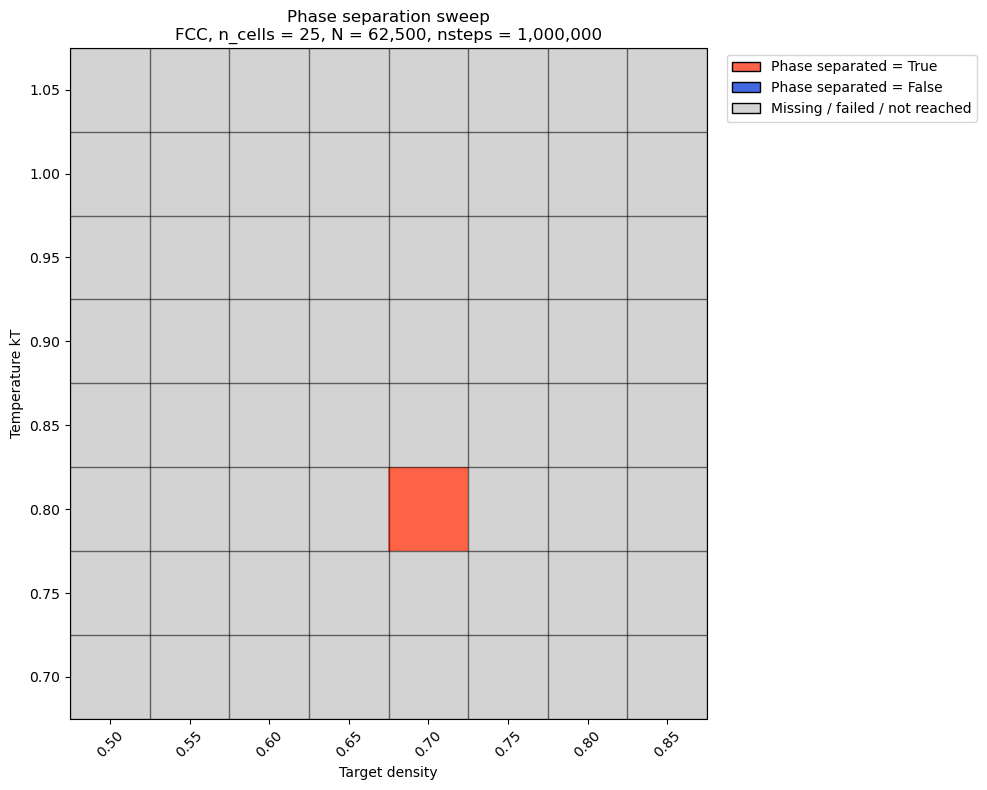

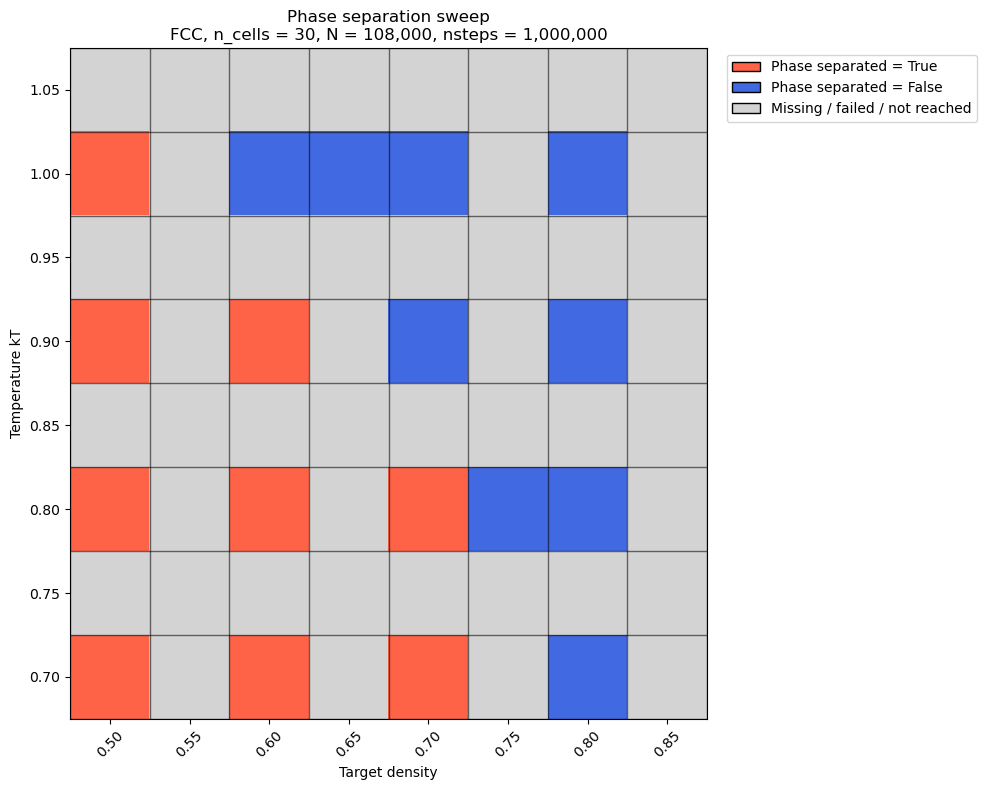

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from md_Helpers import paths, master_csv

def build_phase_status_table(
    n_fcc_cells_values,
    temperatures,
    densities,
    nsteps=1_000_000,
    seed=1,
    n_last=100,
):
    rows = []

    for ncells in n_fcc_cells_values:
        for temp in temperatures:
            for density in densities:
                p = paths.thermalized_run_paths(
                    n_fcc_cells=ncells,
                    target_rho=density,
                    kT=temp,
                    nsteps=nsteps,
                    seed=seed,
                )

                state_path = Path(p["state_path"])
                log_path = Path(p["log_path"])

                row = {
                    "n_fcc_cells": int(ncells),
                    "N": 4 * int(ncells) ** 3,
                    "kT": float(temp),
                    "target_rho": float(density),
                    "state_exists": state_path.exists(),
                    "log_exists": log_path.exists(),
                    "state_path": str(state_path),
                    "log_path": str(log_path),
                    "status": "missing",
                    "phase_separated": np.nan,
                }

                if state_path.exists() and log_path.exists():
                    summary = master_csv.summarize_thermalization_log(
                        log_path,
                        n_last=n_last,
                    )
                    row.update(summary)
                    row["status"] = summary.get("status", "completed")
                    row["phase_separated"] = bool(
                        summary.get("phase_separated", False)
                    )

                rows.append(row)

    return pd.DataFrame(rows)


def plot_phase_grid(status, ncells, nsteps=1_000_000):
    df = status[status["n_fcc_cells"].astype(int) == int(ncells)].copy()

    densities = sorted(df["target_rho"].unique())
    temps = sorted(df["kT"].unique())

    grid = np.full((len(temps), len(densities)), 2)

    for _, row in df.iterrows():
        y = temps.index(row["kT"])
        x = densities.index(row["target_rho"])

        if row["status"] != "completed":
            grid[y, x] = 2
        elif bool(row["phase_separated"]):
            grid[y, x] = 0
        else:
            grid[y, x] = 1

    cmap = ListedColormap(["tomato", "royalblue", "lightgray"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.imshow(
        grid,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        norm=norm,
    )

    ax.set_xticks(np.arange(len(densities)))
    ax.set_xticklabels([f"{rho:.2f}" for rho in densities], rotation=45)

    ax.set_yticks(np.arange(len(temps)))
    ax.set_yticklabels([f"{temp:.2f}" for temp in temps])

    ax.set_xlabel("Target density")
    ax.set_ylabel("Temperature kT")

    N = 4 * int(ncells) ** 3
    ax.set_title(
        "Phase separation sweep\n"
        f"FCC, n_cells = {int(ncells)}, N = {N:,}, nsteps = {nsteps:,}"
    )

    ax.set_xticks(np.arange(-0.5, len(densities), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(temps), 1), minor=True)
    ax.grid(which="minor", color="black", linewidth=1, alpha=0.55)
    ax.tick_params(which="minor", bottom=False, left=False)

    legend_items = [
        Patch(facecolor="tomato", edgecolor="black", label="Phase separated = True"),
        Patch(facecolor="royalblue", edgecolor="black", label="Phase separated = False"),
        Patch(facecolor="lightgray", edgecolor="black", label="Missing / failed / not reached"),
    ]
    ax.legend(handles=legend_items, bbox_to_anchor=(1.02, 1), loc="upper left")

    fig.tight_layout()
    return fig, ax

status = build_phase_status_table(
    n_fcc_cells_values=eos_n_fcc_cells,
    temperatures=eos_temps,
    densities=eos_densities,
    nsteps=1_000_000,
)

for ncells in eos_n_fcc_cells:
    fig, ax = plot_phase_grid(status, ncells, nsteps=1_000_000)
    plt.show()